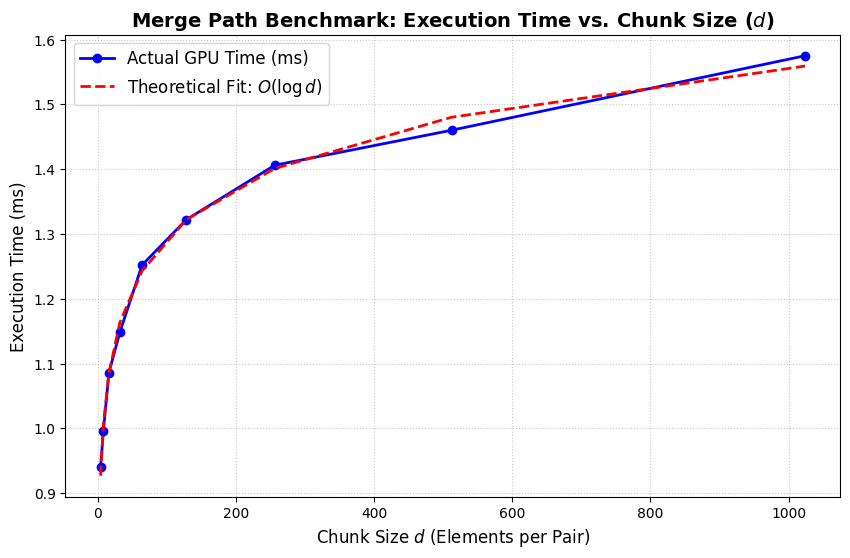

Logarithmic Fit Equation: Time = 0.0790 * log2(d) + 0.7689


In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Your benchmark data
d_values = np.array([4, 8, 16, 32, 64, 128, 256, 512, 1024])
time_ms = np.array([0.941, 0.996, 1.086, 1.149, 1.252, 1.322, 1.406, 1.460, 1.575])

# 2. Calculate the theoretical log(d) fit
# We fit a line to the equation: time = a * log2(d) + b
log2_d = np.log2(d_values)
coefficients = np.polyfit(log2_d, time_ms, 1) # Linear fit on the log values
poly_function = np.poly1d(coefficients)
theoretical_time = poly_function(log2_d)

# 3. Create the plot
plt.figure(figsize=(10, 6))

# Plot actual data
plt.plot(d_values, time_ms, marker='o', linestyle='-', color='blue', linewidth=2, label='Actual GPU Time (ms)')

# Plot theoretical curve
plt.plot(d_values, theoretical_time, linestyle='--', color='red', linewidth=2, label='Theoretical Fit: $O(\log d)$')

# 4. Formatting for a professional report
plt.title('Merge Path Benchmark: Execution Time vs. Chunk Size ($d$)', fontsize=14, fontweight='bold')
plt.xlabel('Chunk Size $d$ (Elements per Pair)', fontsize=12)
plt.ylabel('Execution Time (ms)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=12)

# Optional: Set x-axis to log scale to show the points evenly spaced
# plt.xscale('log', base=2) 

# Save the image in high resolution for your report
plt.savefig('benchmark_plot.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

print(f"Logarithmic Fit Equation: Time = {coefficients[0]:.4f} * log2(d) + {coefficients[1]:.4f}")

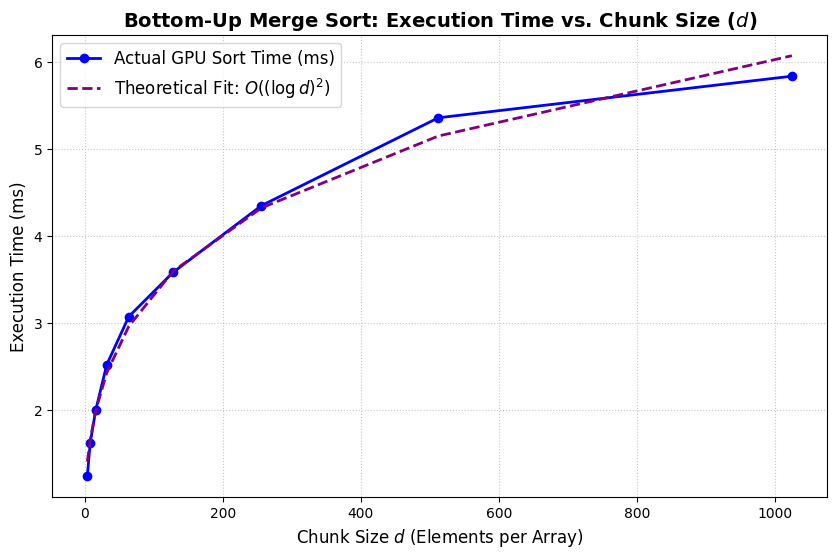

Log-Squared Fit Equation: Time = 0.0486 * (log2(d))^2 + 1.2157


In [1]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Enter the data printed from your terminal here!
d_values = np.array([4, 8, 16, 32, 64, 128, 256, 512, 1024])
time_ms = np.array([ 1.247, 1.618, 1.998, 2.522, 3.076, 3.583, 4.350, 5.359, 5.837])

# 2. Calculate the theoretical (log(d))^2 fit
# We fit a line to the equation: time = a * (log2(d))^2 + b
log2_d_squared = (np.log2(d_values))**2
coefficients = np.polyfit(log2_d_squared, time_ms, 1) 
poly_function = np.poly1d(coefficients)
theoretical_time = poly_function(log2_d_squared)

# 3. Create the plot
plt.figure(figsize=(10, 6))
plt.plot(d_values, time_ms, marker='o', linestyle='-', color='blue', linewidth=2, label='Actual GPU Sort Time (ms)')
plt.plot(d_values, theoretical_time, linestyle='--', color='purple', linewidth=2, label='Theoretical Fit: $O((\log d)^2)$')

# 4. Formatting
plt.title('Bottom-Up Merge Sort: Execution Time vs. Chunk Size ($d$)', fontsize=14, fontweight='bold')
plt.xlabel('Chunk Size $d$ (Elements per Array)', fontsize=12)
plt.ylabel('Execution Time (ms)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=12)

# Save and Show
plt.savefig('sort_benchmark_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Log-Squared Fit Equation: Time = {coefficients[0]:.4f} * (log2(d))^2 + {coefficients[1]:.4f}")

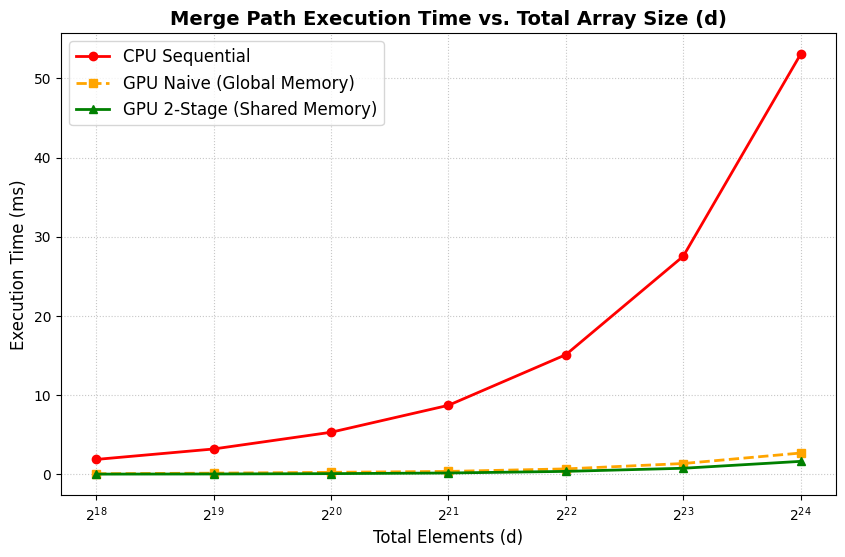

At d = 16.7M elements:
-> 2-Stage is 32.1x faster than the CPU.
-> 2-Stage is 1.64x faster than the Naive GPU approach.


In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter

# 1. Extract the data
d_values = np.array([262144, 524288, 1048576, 2097152, 4194304, 8388608, 16777216])

# CPU times from the second table
cpu_ms = np.array([1.895, 3.215, 5.324, 8.725, 15.116, 27.540, 53.052])

# GPU times from the first table
naive_ms = np.array([0.092, 0.164, 0.268, 0.385, 0.702, 1.381, 2.705])
stage2_ms = np.array([0.042, 0.060, 0.103, 0.183, 0.389, 0.783, 1.653])

# 2. Create the plot
plt.figure(figsize=(10, 6))

# Plot all three lines with distinct colors and markers
plt.plot(d_values, cpu_ms, marker='o', linestyle='-', color='red', linewidth=2, label='CPU Sequential')
plt.plot(d_values, naive_ms, marker='s', linestyle='--', color='orange', linewidth=2, label='GPU Naive (Global Memory)')
plt.plot(d_values, stage2_ms, marker='^', linestyle='-', color='green', linewidth=2, label='GPU 2-Stage (Shared Memory)')

# 3. Formatting
plt.title('Merge Path Execution Time vs. Total Array Size (d)', fontsize=14, fontweight='bold')
plt.xlabel('Total Elements (d)', fontsize=12)
plt.ylabel('Execution Time (ms)', fontsize=12)

# Use a log scale
plt.xscale('log', base=2)
# plt.yscale('log')

# Format the Y-axis ticks to show normal numbers instead of scientific notation (10^1)
ax = plt.gca()
# ax.yaxis.set_major_formatter(ScalarFormatter())
# ax.yaxis.set_minor_formatter(ScalarFormatter())

# Add grid lines for readability
plt.grid(True, which="both", linestyle=':', alpha=0.7)
plt.legend(fontsize=12)

# Add grid lines for readability
plt.grid(True, which="both", linestyle=':', alpha=0.7)
plt.legend(fontsize=12)

# Save the figure in high resolution for your report
plt.savefig('benchmark_cpu_vs_gpu.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

# Calculate the final speedups for the report
speedup_cpu_vs_2stage = cpu_ms[-1] / stage2_ms[-1]
speedup_naive_vs_2stage = naive_ms[-1] / stage2_ms[-1]

print(f"At d = 16.7M elements:")
print(f"-> 2-Stage is {speedup_cpu_vs_2stage:.1f}x faster than the CPU.")
print(f"-> 2-Stage is {speedup_naive_vs_2stage:.2f}x faster than the Naive GPU approach.")